In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm

import sys
sys.path.insert(0, "../func_py/")
import data_utils as dtu
import infer_memplasm as mp

metadata = pd.read_csv('metadata/metadata.tsv', sep='\t', index_col=0)

### Choose the patient by setting the string in the first line
Allowed patients: AT, IM, IZ

In [6]:
pat = 'AT'
mem_samp = [pat+'_t1_mem', pat+'_t2_mem', pat+'_t3_mem']
pb_samp = [pat+'_t1_pb', pat+'_t2_pb', pat+'_t3_pb']
sp_counts, pars = mp.import_data(mem_samp, pb_samp, fam_type='family')
nb_a_mem = dtu.read_noise_negbin_a('inference/noise/', mem_samp)
nb_a_pb = dtu.read_noise_negbin_a('inference/noise/', pb_samp)
dtimes = [1/12, 11/12]
dts = [0.005, 0.005]

gbm_pars = dtu.read_pars('inference/gbm/pat'+pat+'.txt')
tau_m = 10
theta_m = gbm_pars['average_alpha'] * tau_m / 2.0
M_tot = 10**10
n0 = M_tot / gbm_pars['M/n0']

count label not found, setting the counts to 1
count label not found, setting the counts to 1
count label not found, setting the counts to 1
count label not found, setting the counts to 1
count label not found, setting the counts to 1
count label not found, setting the counts to 1
one or more samples do not have a lerned model, the parameter is set as the average of the others
one or more samples do not have a lerned model, the parameter is set as the average of the others


In [7]:
gbm_pars

{'n_points': 300000.0,
 'M/n0': 2108628.1500108596,
 'M/n0_err': 22800.468811306757,
 'n0_low': 4742.419852427987,
 'n0_high': 47424.19852427987,
 'tau_low_bound': 3.2356503065020292,
 'average_alpha': 1.2883276296214698,
 'std_alpha': 0.007626011936904501,
 'birth_rate_bound': 145847.2892933805,
 'N_low': 3994396.129294323,
 'N_high': 5081010.9631658355}

In [8]:
mp_pars = mp.mp_infer_pars(
    dtimes=dtimes, sample_indexes=[pars['m_ids'], pars['p_ids']],
    tau_m=tau_m, theta_m=theta_m, Mm_tot=M_tot, n0=n0,
    m_der_f=0.5, p_to_m=0.1, 
    n_eval=5*10**5, prior_pars=[5,4], dts=dts, n1_min=0
)

#%time ll, fr = mp.log_like_MC(sp_counts, 0.1, 0.3, mp_pars)
#print(ll)

### Visualizing the likelihood
Which we find very flat for sufficiently small alpha

In [9]:
taus = np.logspace(np.log10(0.01), np.log10(10), 15)
alphas = np.logspace(np.log10(0.03), np.log10(0.6), 15)
lls = np.zeros((len(taus), len(alphas)))
progress = tqdm(total=len(taus)*len(alphas))
for i, t in enumerate(taus):
    for j, a in enumerate(alphas):
        th = a * t / 2
        for k in range(len(mp_pars.dts)-1):
            mp_pars.dts[k+1] = min(0.01, min(t, th) / 3)
        ll, fr = mp.log_like_MC(sp_counts, t, th, mp_pars)
        lls[i,j] = ll
        progress.update(1)
        lts = "%3.2f"%np.log10(t)
        astr = "%3.2f"%a
        #print(lts, astr, lls[i,j])

  0%|          | 0/225 [00:00<?, ?it/s]

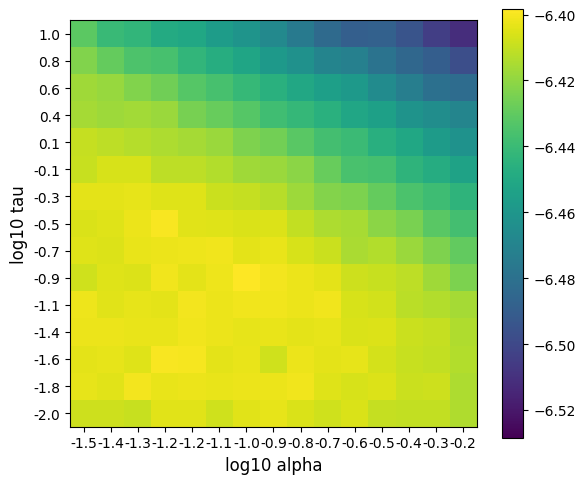

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(6,5))

vmax = np.max(lls)
ax = mp.plot_heatmap(ax, lls, np.log10(alphas), np.log10(taus), vmax-0.13, vmax, labx='log10 alpha', laby='log10 tau', cb=True)
    
plt.tight_layout()
#plt.savefig('plots/memplasm/ll_scan_pat'+pat+'_mder'+str(mp_pars.p_to_m)+'_create.svg', facecolor='w')